In [37]:
suppressWarnings(
  suppressPackageStartupMessages({
    library(misha)
    library(misha.ext)
    library(zoo)
    library(tglkmeans)
    library(data.table)
    library(tidyverse)
    library(tgstat)
    library(prego)
    library(tgutil)
    library(here)
    library(pheatmap)
  })
)

options(gmax.data.size = 1e10)
options(gmultitasking = FALSE)

link_dir =  paste0(here(),'/')
setwd(here())
gsetroot(paste0(link_dir,'data/mm10/'))
gdb.reload()

source(paste0(link_dir,'code/seq2epi_utils.r'))
source(paste0(link_dir,'code/fig_fun.r'))

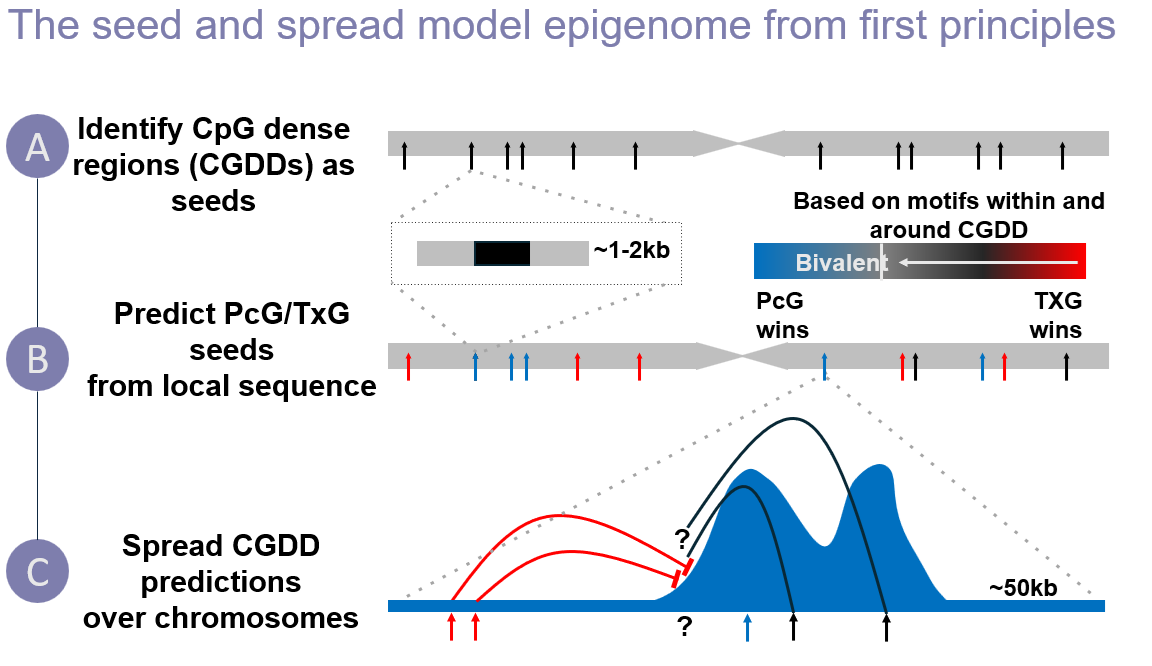

## In this notebook, we examine step C of our algorithm using mouse epiblast and human ESC data.

In [38]:
mod = init_pipe()

done track quant

done cnt track quant

done lib



`pcg_build_gw_feats()` builds sequence-derived features for each
200 bp genomic interval. This step requires heavy computation
and all required packages to be installed.

Therefore, in this notebook we will load the precomputed output
of this function.

In [3]:

#mod = pcg_build_gw_feats(mod = mod,brz = 'lm')

set vt for marginal

lm 10% test noX final



[1] "ok"


Warning message in min(cg_trace$deep_base, na.rm = T):
“no non-missing arguments to min; returning Inf”
Warning message in max(cg_trace$deep_base, na.rm = T):
“no non-missing arguments to max; returning -Inf”
Warning message in min(cg_trace$GC, na.rm = T):
“no non-missing arguments to min; returning Inf”
scale 2

scale 4

scale 8

scale 16

scale 32

scale 64

scale 128

scale 256

scale 512

scale 1024

scale 2048

scale 4096



In [4]:

#saveRDS(mod$gw$cg_trace,'data/files/cg_trace_mm10_new.rds')

#saveRDS(mod$gw$feats,'data/files/feats_mm10_new.rds')

#saveRDS(mod$gw$feats35,'data/files/feats35_mm10_new.rds')

#saveRDS(mod$gw$feats_iqdn,'data/files/feats_iqdn_mm10_new.rds')

In [5]:
1

[1] 1

In [39]:
mod$gw = list()
mod$gw$cg_trace = readRDS('./data/files/cg_trace_mm10.rds')
mod$gw$feats = readRDS('./data/files/feats_mm10.rds')
mod$gw$feats35 = readRDS('./data/files/feats35_mm10.rds')
mod$gw$feats_iqdn = readRDS('./data/files/feats_iqdn_mm10.rds')

**Fig. 2A. Effect of neighboring CGDDs on PcG and TrxG predictions.**

Proximity to a PcG-favoring CGDD is correlated with increased PcG occupancy
at nearby CGDDs, beyond their intrinsic sequence preference.

In contrast, prediction of a TrxG CGDD is not significantly affected by the
proximity of either TrxG- or PcG-favoring elements.

Boxplots show the distribution of observed normalized PcG levels at CGDD seeds
grouped according to sequence-based model predictions.

Purple – CGDDs located near (<10 kb) a predicted PcG CGDD.  
Pink – CGDDs located near (<10 kb) a predicted TrxG CGDD.


  mix   pcg   txg 
10548  2946  5370 

comp ranges

done ranges

bplt

comp ranges

done ranges

bplt

comp ranges

done ranges

bplt

comp ranges

done ranges

bplt



NULL
NULL


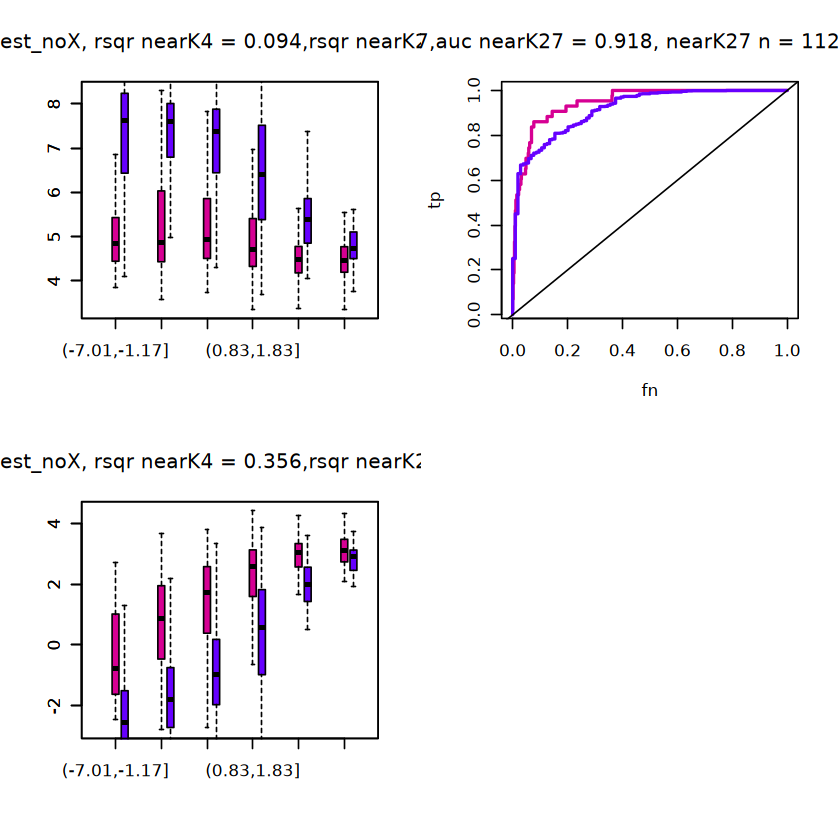

In [11]:
#
inference_intervals = fread('./data/files/inference_intervals.csv')


inference_intervals_noX = inference_intervals %>% filter(chrom !='chrX')

#lm seeds
seeds = readRDS('./data/files/lm_10test_noX_seeds_logist_dinucs_logist_fig1.rds')


f_pcg = seeds$modality=='pcg'
f_txg = seeds$modality=='txg'
f_mix = seeds$modality=='mix'
seeds$pred_seed_k27 = seeds$k27_pred
seeds$pred_seed_k4 = seeds$k4_pred
seeds$k27_resp = seeds$eb4_k27_mean##!!!

seeds$modality_temp = ifelse(seeds$pred_seed_k27>6.4,'pcg','mix')
seeds$modality_temp  = ifelse(seeds$pred_seed_k4 >= 6 & seeds$pred_seed_k27 < 5.3,
                               'txg',seeds$modality_temp )
table(seeds$modality_temp)
pcg_report_cooperativity_bxplts(df=seeds, pred_k27 = seeds$pred_seed_k27,pred_k4=seeds$pred_seed_k4,
                              resp10=inference_intervals_noX$resp10,fit_type='lm_10test_noX',
                                t_k4=6,t_k27=6.4,t_k4_on_k27 = 5.3)

**Fig. 2B. PcG signal spreading from seeds as a function of chromosomal contact probability.**

Our genome wide model uses only sequence encoded features (genomic rules).
PcG spreading is approximated by chromosomal contact probability, modeled as
1 / distance from a predicted seed.

Genome-wide normalized PcG coverage (Y axis) is shown as a function of the
distance to the nearest CGDD (X axis).

Genomic bins are grouped by the predicted identity of the nearest CGDD
(left – PcG, center – mixed, right – TrxG) and by CpG content (color-coded).

runing from precomputed cg_trace

`summarise()` has grouped output by 'bin'. You can override using the `.groups`
argument.
Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_line()`).”
runing from precomputed cg_trace

`summarise()` has grouped output by 'bin'. You can override using the `.groups`
argument.
Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_line()`).”
runing from precomputed cg_trace

`summarise()` has grouped output by 'bin'. You can override using the `.groups`
argument.


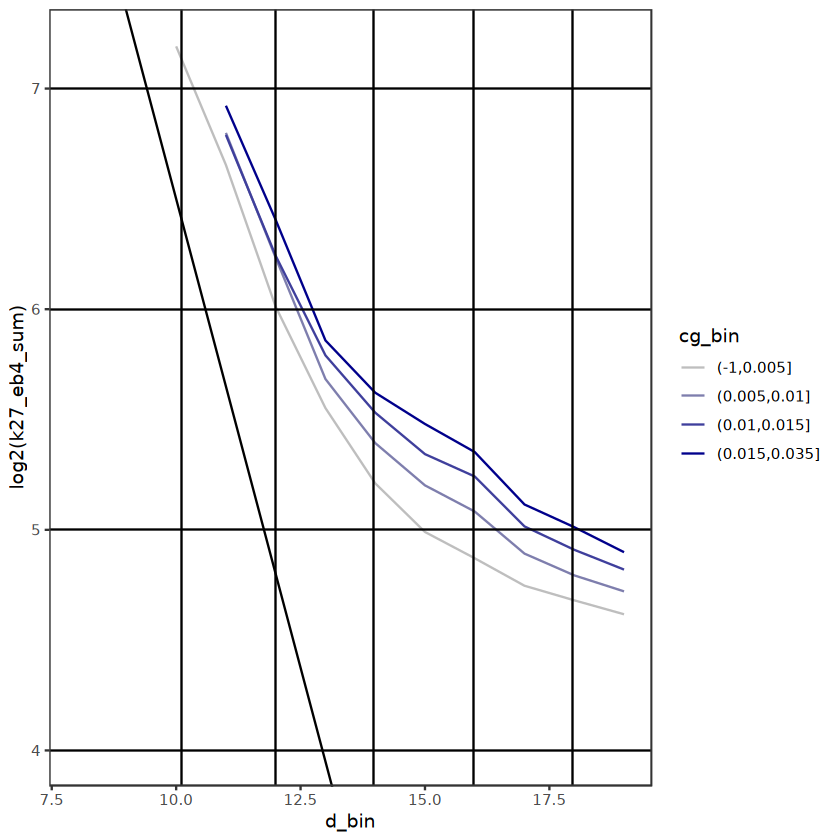

Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 12 rows containing missing values or values outside the scale range
(`geom_line()`).”
Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/decay1.pptx

Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_line()`).”
Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/decay2.pptx

Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_line()`).”
Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/decay3.pptx



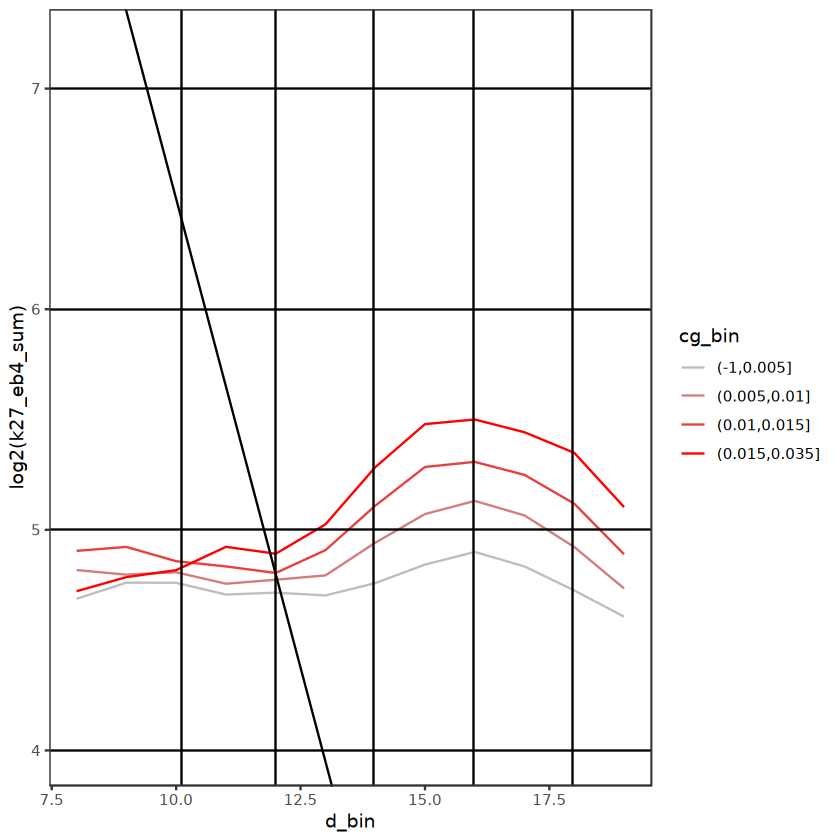

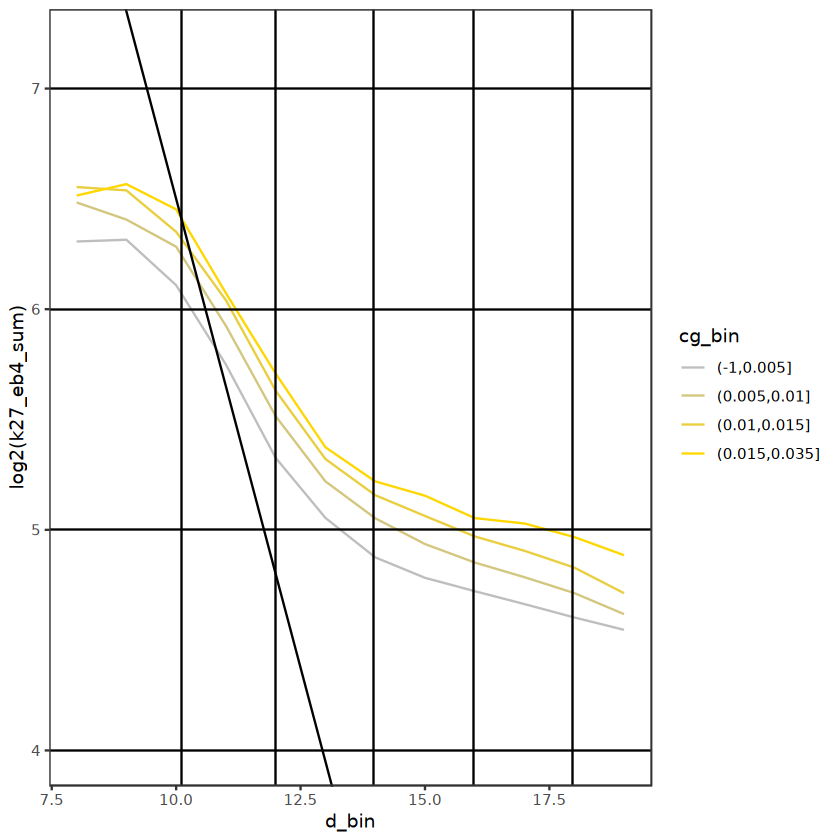

In [42]:
mod$gw$cg_trace = readRDS('./data/files/cg_trace_mm10.rds')
generate_decay_new()

**Genome-wide model training**

Due to the new *misha* version (see Fig. 1 notebook), we observe
minor differences in the training results.

The change in R² is:
0.464951556378983 − 0.46557141117536 = −0.00062.

Below we show both training results for comparison.

In [13]:
##Old version misha
mod$gw = list()
mod$gw$cg_trace = readRDS('./data/files/cg_trace_mm10.rds')
mod$gw$feats = readRDS('./data/files/feats_mm10.rds')
mod$gw$feats35 = readRDS('./data/files/feats35_mm10.rds')
mod$gw$feats_iqdn = readRDS('./data/files/feats_iqdn_mm10.rds')

mod = pcg_build_gw_pred(mod,  rebuild_iqdn=T, rebuild_base=F,test_borzoi = TRUE, rebuild_atac=F,perc_genome = 0)
mod$gw$mods_stat$base2iqdn
mod$gw$cg_trace$pred = mod$gw$xg_pred$base2iqdn

f_norp is 7915223

test chromosomes chr10chr14chr15chr4

start training 



formu 
"resp ~  ld_mix+ld_pcg+ld_txg+min_dcg+cgmix_1+cgmix_2+cgmix_3+cgmix_4+cgmix_5+cgmix_6+cgmix_7+cgmix_8+cgmix_9+cgmix_10+cgmix_11+cgtxg_1+cgtxg_2+cgtxg_3+cgtxg_4+cgtxg_5+cgtxg_6+cgtxg_7+cgtxg_8+cgtxg_9+cgtxg_10+cgtxg_11+cgpcg_1+cgpcg_2+cgpcg_3+cgpcg_4+cgpcg_5+cgpcg_6+cgpcg_7+cgpcg_8+cgpcg_9+cgpcg_10+cgpcg_11+GC+CG+dltr+dline+ldltr+ldline+pred_seed_k27+pred_seed_k4+GC20_l1+GC20_l1.1+GC20_l2+GC20_l3+GC20_l4+GC20_r1+GC20_r2+GC20_r3+GC20_r4+CG20_l1+CG20_l1.1+CG20_l2+CG20_l3+CG20_l4+CG20_r1+CG20_r2+CG20_r3+CG20_r4+mix2+pcg2+DeepTop+DeepTop2k+DeepTop20k+DeepTop200k+IQ+IQ2k+IQ20k+IQ200k + GC*CG" 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       lm_r2_test 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               "0.39627530742968" 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      lm_r2_train 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              "0.398021041349122" 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   lm_r2_test_all 
                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [6]:
mod = pcg_build_gw_pred(mod,  rebuild_iqdn=T, rebuild_base=F,test_borzoi = TRUE, rebuild_atac=F,perc_genome = 0)
mod$gw$mods_stat$base2iqdn
#mod$gw$cg_trace$pred = mod$gw$xg_pred$base2iqdn

f_norp is 7915223

test chromosomes chr10chr14chr15chr4

start training 



formu 
"resp ~  ld_mix+ld_pcg+ld_txg+min_dcg+cgmix_1+cgmix_2+cgmix_3+cgmix_4+cgmix_5+cgmix_6+cgmix_7+cgmix_8+cgmix_9+cgmix_10+cgmix_11+cgtxg_1+cgtxg_2+cgtxg_3+cgtxg_4+cgtxg_5+cgtxg_6+cgtxg_7+cgtxg_8+cgtxg_9+cgtxg_10+cgtxg_11+cgpcg_1+cgpcg_2+cgpcg_3+cgpcg_4+cgpcg_5+cgpcg_6+cgpcg_7+cgpcg_8+cgpcg_9+cgpcg_10+cgpcg_11+GC+CG+dltr+dline+ldltr+ldline+pred_seed_k27+pred_seed_k4+GC20_l1+GC20_l1.1+GC20_l2+GC20_l3+GC20_l4+GC20_r1+GC20_r2+GC20_r3+GC20_r4+CG20_l1+CG20_l1.1+CG20_l2+CG20_l3+CG20_l4+CG20_r1+CG20_r2+CG20_r3+CG20_r4+mix2+pcg2+DeepTop+DeepTop2k+DeepTop20k+DeepTop200k+IQ+IQ2k+IQ20k+IQ200k + GC*CG" 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       lm_r2_test 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               "0.39627520176837" 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      lm_r2_train 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              "0.398020976927029" 
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   lm_r2_test_all 
                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [ ]:
#save_gw_to_misha(mod,track_nm = "jk.epipcg.pred.eb4_xgb_lm_10test_lg_seeds_gc_cg_noX_final")

comp ranges

done ranges

bplt

comp ranges

done ranges

bplt



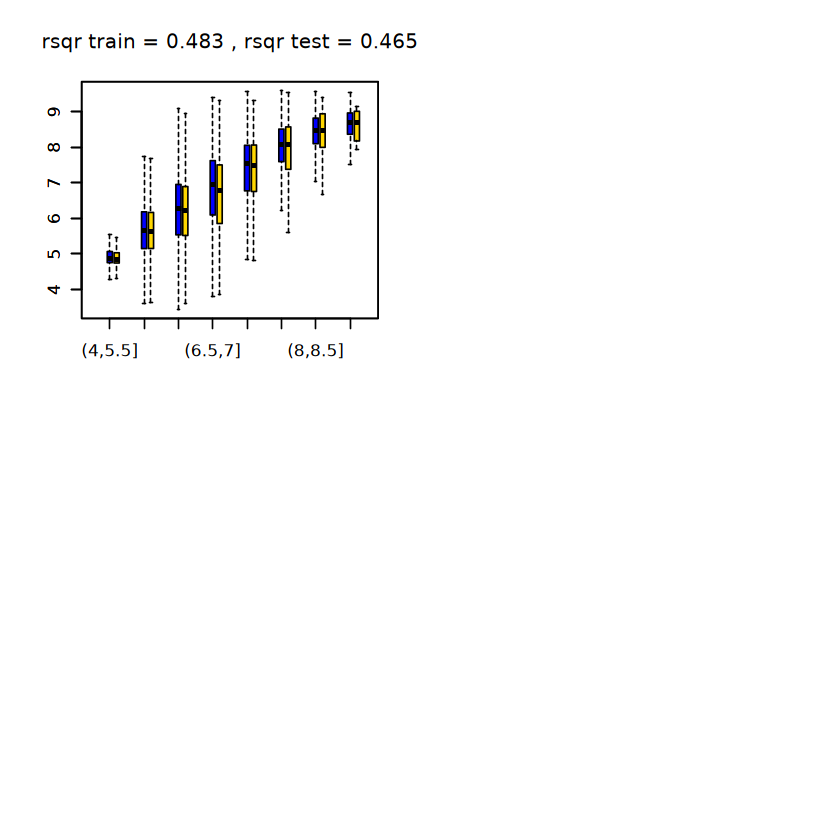

In [43]:

pcg_report_locmod_gw_pptx(mod)

**Fig. 2D. Genome wide model evaluation**

Box plots show distributions of observed mouse PcG coverage in genomic bins 
grouped by ranges of model prediction values. Data from train and test chromosomes 
are shown separatel

comp ranges

done ranges

bplt

comp ranges

done ranges

bplt



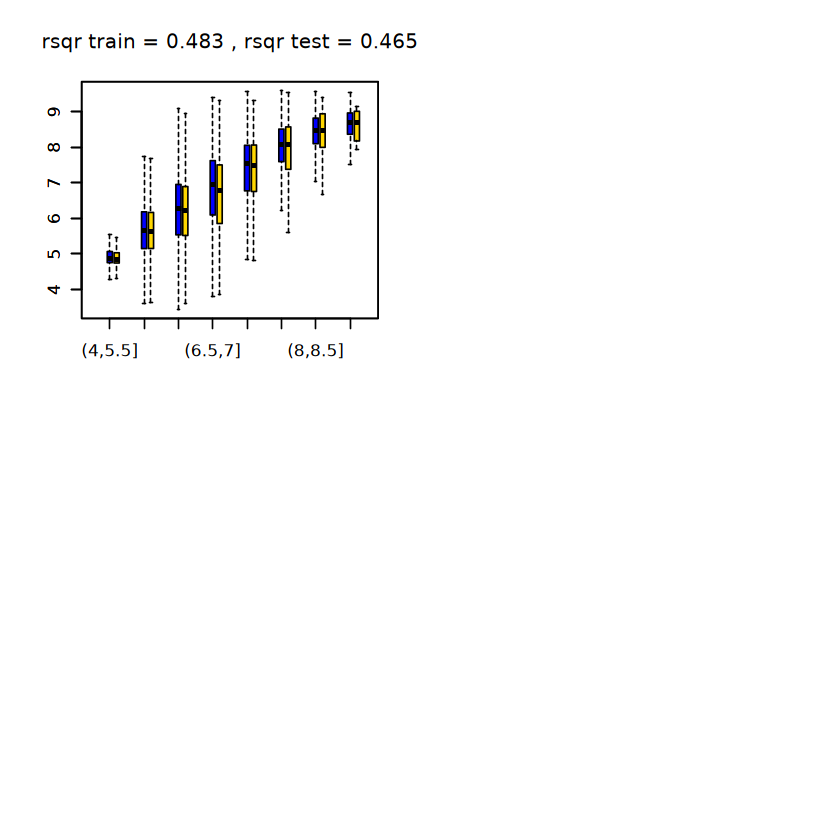

In [82]:

pcg_report_locmod_gw_pptx(mod)

**Fig. 2F. observed PcG and predicted PcG for some PcG domains**


Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/bmp4.pptx

Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/sox2.pptx

Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/gata2.pptx

Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/crabp2.pptx

Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/hoxD.pptx

Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/hoxc.pptx

Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/hoxb.pptx

Saved PPTX to: /net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/evghenic/Proj/polycomb/sns_paper/figs/hoxa.pptx



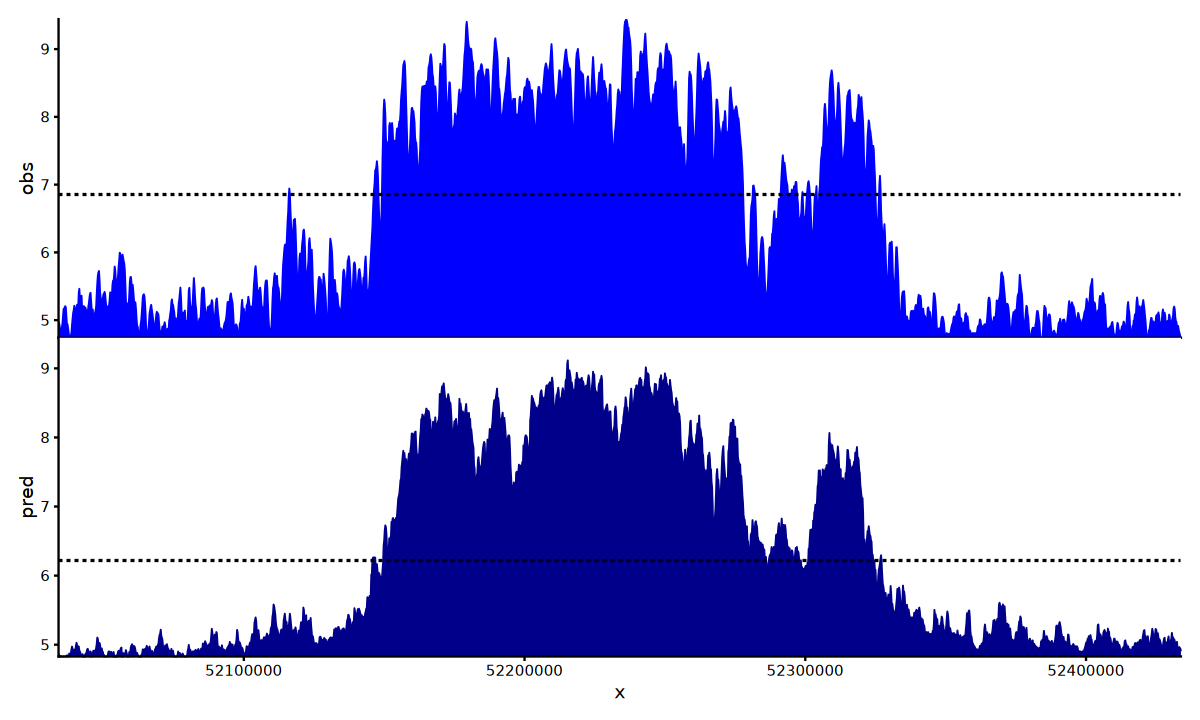

In [87]:
##print observed PcG and predicted PcG for some PcG domains
sps(10,6)
horiz = 2e5
gg = plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,
				chrom = as.character('chr6'), locus =52233936, 
				label_tss = F,
				fn="figs/GW_hoxa.pdf", fn_w = 15, fn_h=10,
				more_tracks=c())
print(gg)

horiz = 1e5
gg <- plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,
                             chrom = as.character('chr14'), locus = 46390668,
                             label_tss = F,
                             fn = "figs/bmp4.pdf", fn_w = 15, fn_h = 10,
                             more_tracks = c())
save_gg_to_pptx(gg, path = "./figs/bmp4.pptx")

horiz = .5e5
gg <- plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,
                             chrom = as.character('chr3'), locus = 34650614,
                             label_tss = F,
                             fn = "figs/sox2.pdf", fn_w = 15, fn_h = 10,
                             more_tracks = c())
save_gg_to_pptx(gg, path = "./figs/sox2.pptx")

horiz = 2e5
gg <- plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,
                             chrom = as.character('chr6'), locus = 88199734,
                             label_tss = F,
                             fn = "figs/gata2.pdf", fn_w = 15, fn_h = 10,
                             more_tracks = c())
save_gg_to_pptx(gg, path = "./figs/gata2.pptx")

horiz = 1.5e5
gg <- plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,
                             chrom = as.character('chr3'), locus = 87950753,
                             label_tss = F,
                             fn = "figs/crabp2.pdf", fn_w = 15, fn_h = 10,
                             more_tracks = c())
save_gg_to_pptx(gg, path = "./figs/crabp2.pptx")

horiz = 1.5e5
gg <- plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz + 4.5e4, off3 = horiz,
                             chrom = as.character('chr2'), locus = 74683351,
                             label_tss = F,
                             fn = "figs/GW_hoxd.pdf", fn_w = 15, fn_h = 10,
                             more_tracks = c())
save_gg_to_pptx(gg, path = "./figs/hoxD.pptx")

horiz = 4.5e5
gg <- plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,
                             chrom = as.character('chr15'), locus = 102990409,
                             label_tss = F,
                             fn = "figs/GW_hoxc.pdf", fn_w = 15, fn_h = 10,
                             more_tracks = c())
save_gg_to_pptx(gg, path = "./figs/hoxc.pptx")

horiz = 2.5e5
gg <- plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,
                             chrom = as.character('chr11'), locus = 96284150,
                             label_tss = F,
                             fn = "figs/GW_hoxb.pdf", fn_w = 15, fn_h = 10,
                             more_tracks = c())
save_gg_to_pptx(gg, path = "./figs/hoxb.pptx")

horiz = 2e5
gg <- plt_genome_pred_png_gg(mod, g = NA, off5 = -horiz, off3 = horiz,
                             chrom = as.character('chr6'), locus = 52233936,
                             label_tss = F,
                             fn = "figs/GW_hoxa.pdf", fn_w = 15, fn_h = 10,
                             more_tracks = c())
save_gg_to_pptx(gg, path = "./figs/hoxa.pptx")


In [ ]:
**Fig. 2G. observed PcG and predicted PcG for some PcG domains**


In [88]:
work = readRDS('./tables/sns_fig1_work_mm10.rds')
dir.create(here("figs/cgd_mod_atac_legend"), showWarnings = F, recursive = T)
pcg_plot_atac_heats(work = work, base_dir = "figs/cgd_mod_atac_legend",legend = TRUE)

Warning message in .fun(.value[0], ...):
“no non-missing arguments to max; returning -Inf”


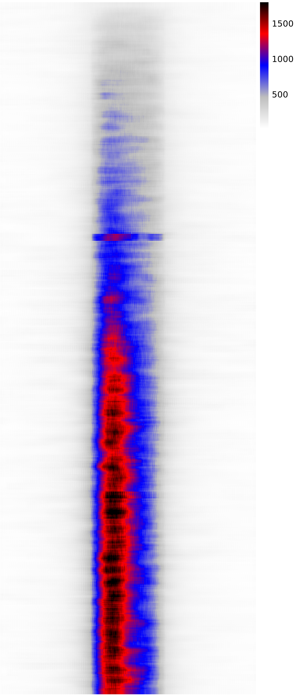

**Fig. 2G. observed PcG and predicted PcG for some PcG domains**


[1] "ES_ch_k4"   "EB4_cnt_k4"

set vt for marginal

set vt for marginal



[1] "gext"
NULL


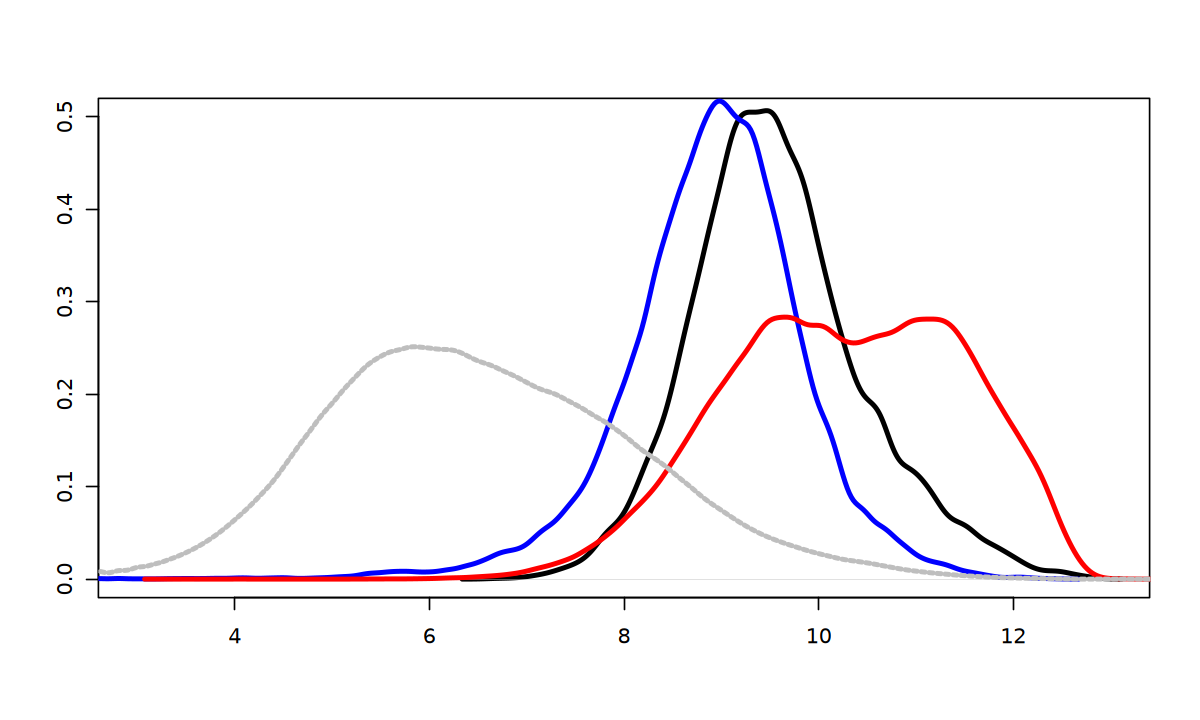

In [105]:
gen_k27_vt(mod)
gen_k4_vt(mod)
gen_track_vext()
plot_atac_cgd_bin_distrib(mod=mod)

In [ ]:
####FIG3 EDF

In [108]:
gsetroot(paste0(link_dir,'data/hg19/'))

gdb.reload()

source(paste0(here(),'/code/hgpcg_domains_hg19.r'))
source(paste0(here(),'/code/fig_fun.r'))

mod = hpcg_init()



set vt for marginal



In [11]:
#mod = pcg_build_gw_feats_hg(mod = mod)

set vt for marginal



[1] "cgd_5mc"
   chrom  start    end strand
29  chr1 854709 855088      1
30  chr1 856453 856954      1
32  chr1 864410 864999      1
33  chr1 865328 865705      1
34  chr1 869229 872026      1
35  chr1 872177 872578      1


Warning message in min(cg_trace$GC, na.rm = T):
“no non-missing arguments to min; returning Inf”
Warning message in min(cg_trace$CG, na.rm = T):
“no non-missing arguments to min; returning Inf”


[1] "cg5mc_sc"
     [,1]
[1,]    0
[2,]    0
[3,]    0
[4,]    0
[5,]    0
[6,]    0


scale 2

scale 4

scale 8

scale 16

scale 32

scale 64

scale 128

scale 256

scale 512

scale 1024

scale 2048

scale 4096



In [110]:
mod$gw$cg_trace = readRDS(paste0(here(),'/data/files/files_hg19/cg_trace.rds'))
mod$gw$feats = readRDS(paste0(here(),'/data/files/files_hg19/feats.rds'))
mod$gw$feats35 = readRDS(paste0(here(),'/data/files/files_hg19/feats35.rds'))

In [118]:
mod = pcg_build_gw_pred_hg(mod,  rebuild_iqdn=F, rebuild_base=T, rebuild_atac=F,perc_genome=0)

start training 



In [ ]:
####FIG3 EDF

`summarise()` has grouped output by 'bin'. You can override using the `.groups`
argument.
Warning message:
“Removed 27 rows containing missing values or values outside the scale range
(`geom_line()`).”
`summarise()` has grouped output by 'bin'. You can override using the `.groups`
argument.
Warning message:
“Removed 33 rows containing missing values or values outside the scale range
(`geom_line()`).”
`summarise()` has grouped output by 'bin'. You can override using the `.groups`
argument.


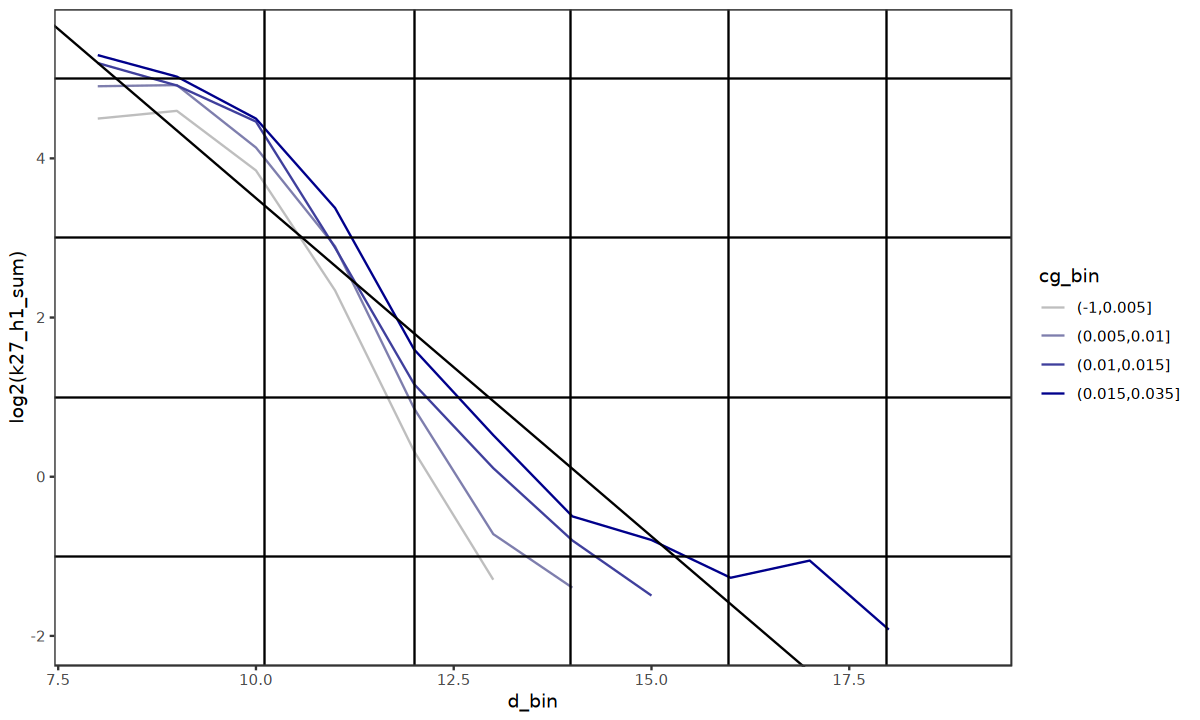

Warning message:
“Removed 35 rows containing missing values or values outside the scale range
(`geom_line()`).”
create an emty presentation file

create an emty presentation file

create an emty presentation file



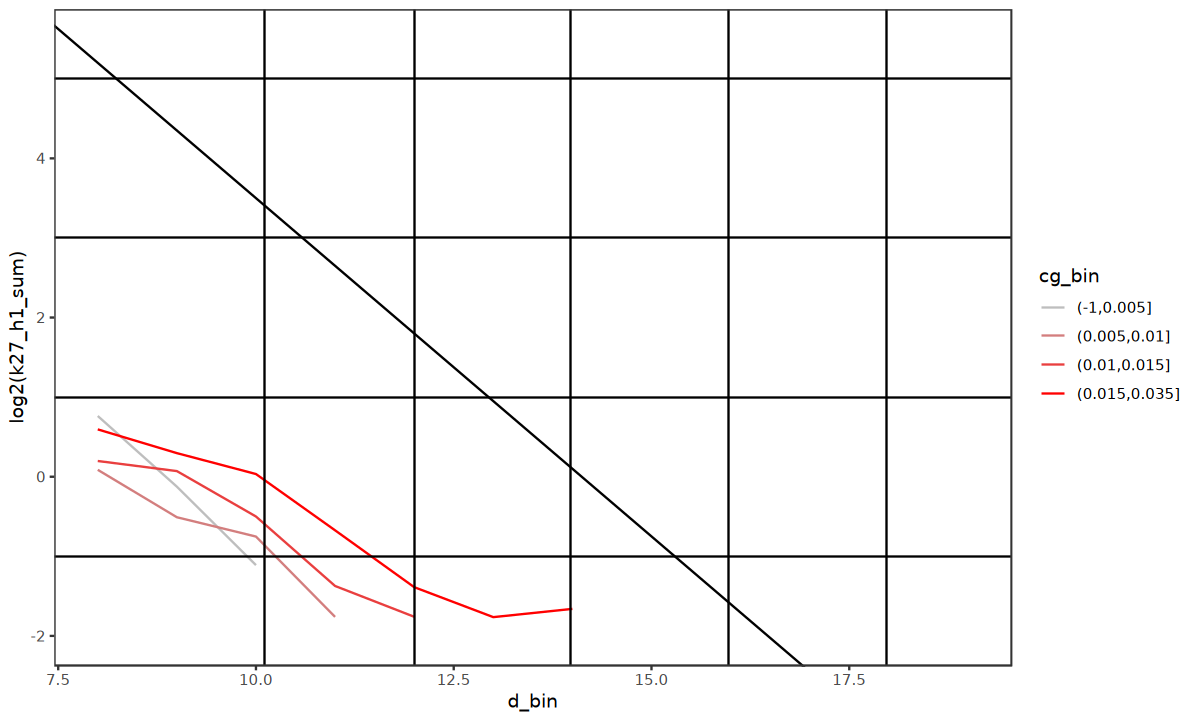

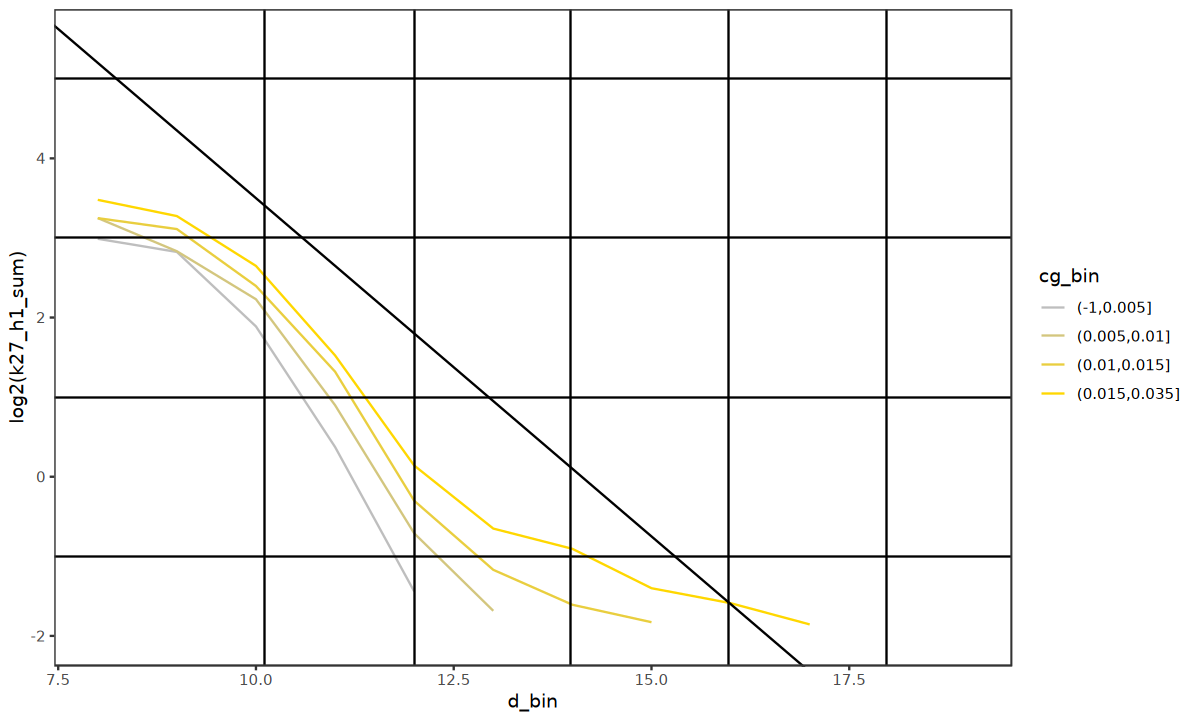

In [111]:
##new on diff 5mc 0.5
generate_decay_hg_new()

In [119]:
#
mod$gw$mods_stat$base

$formu
[1] "resp ~  ld_mix+ld_pcg+ld_txg+min_dcg+cgmix_1+cgmix_2+cgmix_3+cgmix_4+cgmix_5+cgmix_6+cgmix_7+cgmix_8+cgmix_9+cgmix_10+cgmix_11+cgtxg_1+cgtxg_2+cgtxg_3+cgtxg_4+cgtxg_5+cgtxg_6+cgtxg_7+cgtxg_8+cgtxg_9+cgtxg_10+cgtxg_11+cgpcg_1+cgpcg_2+cgpcg_3+cgpcg_4+cgpcg_5+cgpcg_6+cgpcg_7+cgpcg_8+cgpcg_9+cgpcg_10+cgpcg_11+GC+CG+tn5b+dltr+dline+ldltr+ldline+cg5mc_1+cg5mc_2+cg5mc_3+cg5mc_4+cg5mc_5+cg5mc_6+cg5mc_7+cg5mc_8+cg5mc_9+cg5mc_10+cg5mc_11+ld_5mc+dblck+ldblck+duke20+dsine+ldsine+dlowc+ldlowc+dsimpr+ldsimr+dbgc+ldbgc+iq_score+iq_score5mc+mix2+pcg2 + GC*CG"

$lm_stat
      lm_r2_test      lm_r2_train   lm_r2_test_all  lm_r2_train_all 
       0.4738283        0.4901640        0.4738283        0.4901640 
lm_auc_999_train  lm_auc_999_test lm_auc_998_train  lm_auc_998_test 
       0.9844955        0.9895702        0.9687677        0.9733753 
lm_auc_997_train  lm_auc_997_test lm_auc_994_train  lm_auc_994_test 
       0.9572273        0.9587489        0.9338020        0.9315927 

$xg_stat
      xg_r2_test      xg_r2_train   xg_r2_test_all  xg_r2_train_all 
       0.4992354        0.5423801        0.4992354        0.5423801 
xg_auc_999_train  xg_auc_999_test xg_auc_998_train  xg_auc_998_test 
       0.9862446        0.9899834        0.9708512        0.9737309 
xg_auc_997_train  xg_auc_997_test xg_auc_994_train  xg_auc_994_test 
       0.9598720        0.9589590        0.9373007        0.9309621 
     xg_n_under4      xg_n_overr4 
    6394.0000000      235.0000000

In [20]:
mod$gw$cg_trace$pred = mod$gw$xg_pred$base

In [24]:
#saveRDS(mod$gw$cg_trace,paste0(here(),'/data/files/files_hg19/cg_trace.rds'))
#saveRDS(mod$gw$feats,paste0(here(),'/data/files/files_hg19/feats.rds'))
#saveRDS(mod$gw$feats35,paste0(here(),'/data/files/files_hg19/feats35.rds'))

In [112]:
pcg_report_locmod_iq_pptx_gw_hg(mod)

comp ranges

done ranges

bplt



comp ranges

done ranges

bplt

comp ranges

done ranges

bplt

comp ranges

done ranges

bplt

comp ranges

done ranges

bplt



NULL
NULL


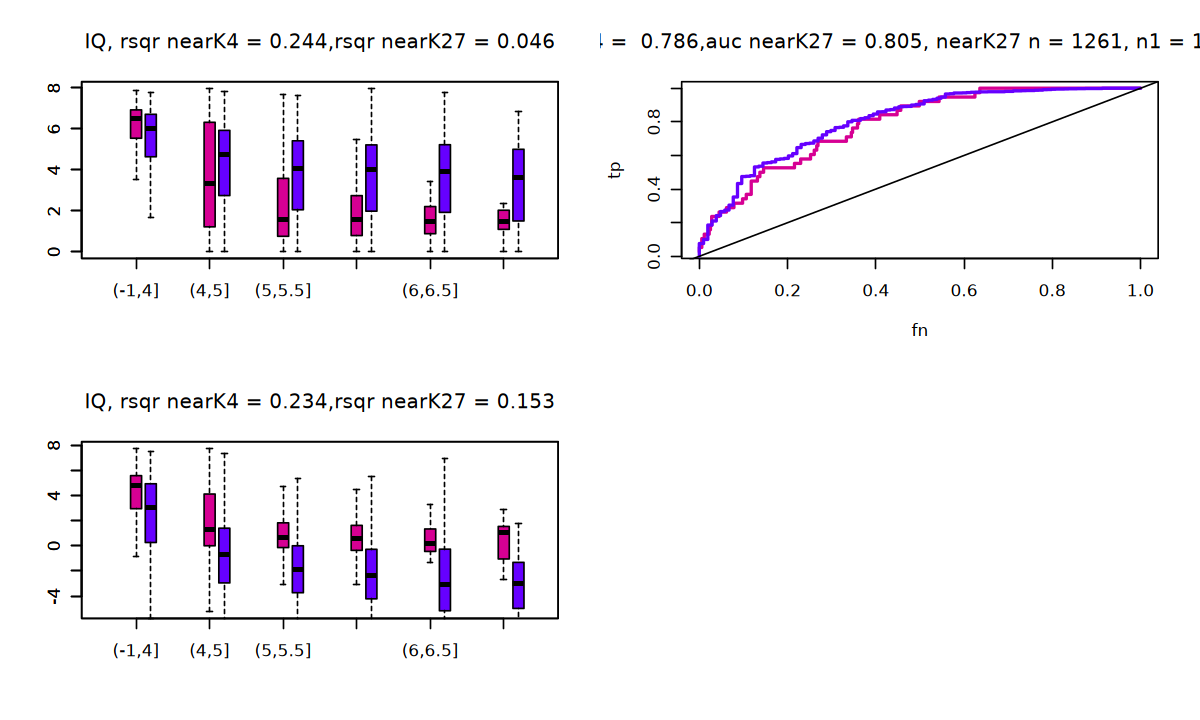

In [114]:
cgdd_iq = fread(here("output/iq-hg19-model_preds-diff-preds.tsv"), sep = "\t")%>%
arrange(chrom,start)
pcg_report_cooperativity_bxplts_hg(df = mod$cgdom_ann,resp10 = cgdd_iq$resp10,pred =mod$cgdom_ann$pred ,t_k4 = 3.8, t_k27 = 5)

NULL

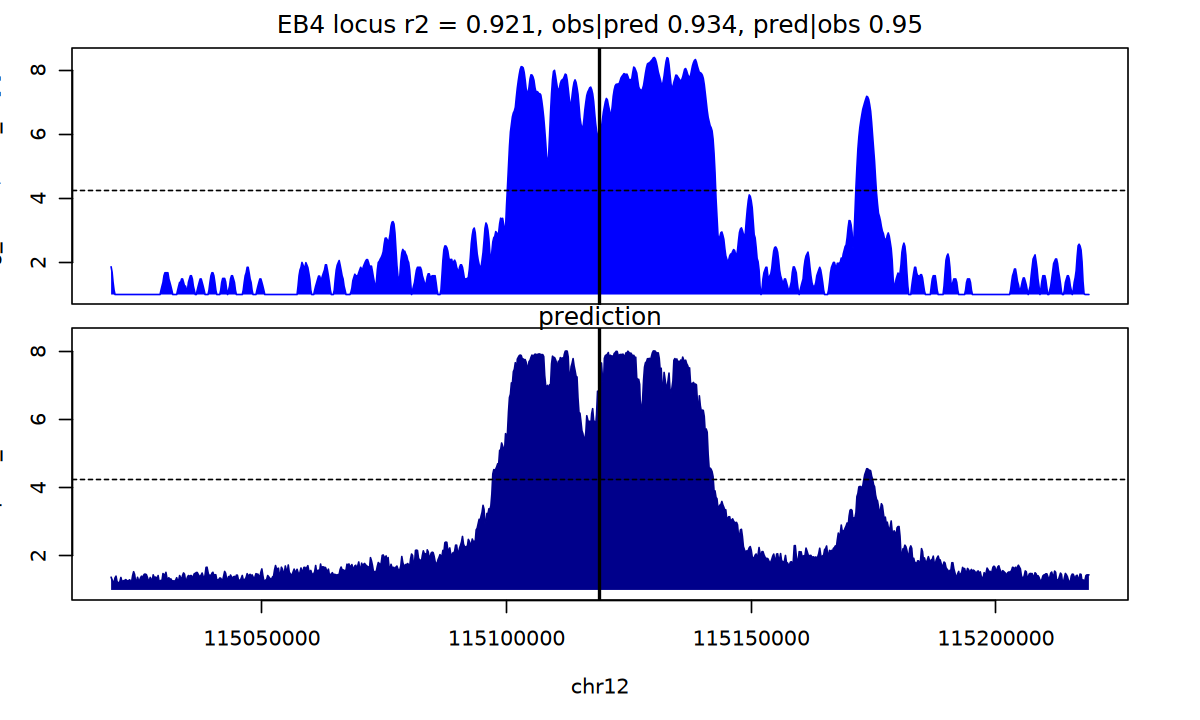

In [116]:
horiz=1e+5
plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = F,
				chrom = as.character('chr12'), locus =115106060+1.3e4, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()) 
horiz=1e+5
save_baseR_to_ppt(plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = F,
				chrom = as.character('chr12'), locus =115106060+1.3e4, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),'./figs/GW_tbx3_hg.pptx')

 horiz=1e+5
save_baseR_to_ppt(plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = F,
				chrom = as.character('chr8'), locus =11532444+2e4, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),'./figs/GW_gata4_hg.pptx')

 horiz=1.5e+5
save_baseR_to_ppt(plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = F,
				chrom = as.character('chr2'), locus =176985278, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),'./figs/GW_hoxd_hg.pptx')

 horiz=4e+5
save_baseR_to_ppt(plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = F,
				chrom = as.character('chr12'), locus =54403908, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),'./figs/GW_hoxc_hg.pptx')

 horiz=2e+5
save_baseR_to_ppt(plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = F,
				chrom = as.character('chr17'), locus =46678145, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),'./figs/GW_hoxb_hg.pptx')

 horiz=1.6e+5
save_baseR_to_ppt(plt_genome_pred_ppt_hg(mod, g = NA, off5 = -horiz, off3 = horiz,label_tss = F,
				chrom = as.character('chr7'), locus =27197628, 
				
				fn="", fn_w = 15, fn_h=10,
				more_tracks=c()),'./figs/GW_hoxa_hg.pptx')